In [ ]:
from halox import lss, cosmology
import jax
import jax.numpy as jnp
import jax_cosmo as jc
from flax import nnx # this is currently unsupported
import optax
import scipy
import matplotlib.pyplot as plt
print(jax.devices())
print(jax.default_backend())

/home/lmoreau/miniforge3/envs/emuenvv4/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


[CudaDevice(id=0)]
gpu


In [2]:
@jax.jit
def halox_trainer(x):
    logM, z, omb, omc, s8, h, ns = x
    # Fixed values, maybe incorporate at least delta_c later?
    n_k_int = 4000 # can go down to ~ 500 but not without issues!!!
    hcosmo = jc.Cosmology(Omega_b=omb, Omega_c=omc, h=h, sigma8=s8, n_s=ns, Omega_k=0, w0=-1, wa=0)
    M = 10**logM # we are doing this because logM is easier to use in the network???
    return jnp.log10(lss.sigma_M(M, z, cosmo=hcosmo, n_k_int=n_k_int))

In [3]:
param_names = ["logM", "z", "omega_b", "omega_c", "sigma8", "h", "n_s"]

bounds = jnp.array([
    [11, 16],   # logMass
    [-0.05, 5],   # z
    [0.01, 0.08],   # Omega_b
    [0.085, 0.5],   # Omega_c
    [0.6, 1.],   # sigma8
    [0.4, 1.],   # h
    [0.8, 1.1],   # n_s
])

mins = bounds[:, 0]
maxs = bounds[:, 1]
ranges = maxs-mins

def normalize(x):
    return (x - mins) / ranges

def denormalize(x_norm):
    
    return x_norm * ranges + mins

d = bounds.shape[0]
n_samples = int(131072*2)

sampler = scipy.stats.qmc.Sobol(d=d, scramble=True)
unit_samples = sampler.random(n_samples)
samples = scipy.stats.qmc.scale(unit_samples, bounds[:,0], bounds[:,1])

In [4]:
yv = jax.vmap(halox_trainer)
y_train = yv(samples)

In [5]:
def train_val_split(x, y, val_frac=0.2, seed=1):
    key = jax.random.PRNGKey(seed)
    N = x.shape[0]

    perm = jax.random.permutation(key, N)

    n_val = int(val_frac * N)

    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    return x[train_idx], y[train_idx], x[val_idx], y[val_idx]

In [6]:
x_train, y_train, x_val, y_val = train_val_split(samples ,y_train)

x_train_norm = normalize(x_train)
x_val_norm = normalize(x_val)

In [7]:
def cosmofrmtheta(theta):
    logM, z, omb, omc, s8, h, ns = theta
    return jc.Cosmology(
        Omega_b = omb,
        Omega_c = omc,
        sigma8 = s8,
        h = h,
        n_s = ns
    )

nw = 64

class MLP(nnx.Module):
    def __init__(self, rngs: nnx.Rngs):
        self.linear1 = nnx.Linear(7, nw, rngs=rngs)
        self.linear2 = nnx.Linear(nw, nw, rngs=rngs)
        self.linear3 = nnx.Linear(nw,nw, rngs=rngs)
        self.linear4 = nnx.Linear(nw, 1, rngs=rngs)

    def __call__(self, x):
        x = nnx.silu(self.linear1(x)) #silu worked WAY better than relu, I wonder why?
        x = nnx.silu(self.linear2(x))
        x = nnx.silu(self.linear3(x))
        x = self.linear4(x)
        return x.squeeze(-1)  # (batch,)


model = MLP(rngs=nnx.Rngs(1))
nnx.display(model)

In [8]:
# ON PLATEAU (parameters good but needs some modification to optimizer to incorporate correctly, (3% on high end only))
plateau = optax.contrib.reduce_on_plateau(
    factor=0.75,
    cooldown=0,
    patience=30,
    accumulation_size = 30,
    rtol=1e-3,
)
start_rate = 1e-3

schedule = optax.warmup_cosine_decay_schedule(
    init_value=start_rate,
    peak_value=25e-4,
    warmup_steps=10000,
    decay_steps=35000,
    end_value=5e-4
)
# Just under 1%, 0.1, 0, 3, 250
# What used to work 0.2, 0, 3, 200
tx = optax.chain(
    optax.adamw(start_rate),
    plateau
)


# 0.9, 10, 50
optimizer = nnx.Optimizer(
    model, 
    optax.adam(schedule),
    wrt=nnx.Param
    ) #optimizes with respect to nnx.Param

def loss_fn(model, x, y):
    predictions = model(x)
    return jnp.mean(((predictions-y))**2)


@nnx.jit #because mutable state
def train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(loss_fn)(model, x, y) # returns new values, not in place replacement
    optimizer.update(model, grads=grads, value = loss) #only grads is needed here, is this backprop
    return loss

In [9]:
n_epochsv2 = 35_000
lossesv2 = []
val = []
val_epochs = []
lr_history = []

for epoch in range(n_epochsv2):
    loss = train_step(model, optimizer, x_train_norm, y_train)
    lossesv2.append(float(loss)) # memory error

    # state = optimizer.opt_state

    # # plateau transform is the last transform in the chain
    # plateau_state = state[-1]

    # lr = start_rate * plateau_state.scale

    # lr_history.append(lr)

    if epoch % 300 == 0 or epoch == n_epochsv2 - 1:
        val_loss = loss_fn(model,x_val_norm,y_val)
        val.append(val_loss)
        val_epochs.append(epoch)
        print(f"Epoch {epoch:>5d} | Loss: {loss:.6f} | Validation Loss: {val_loss:.6f}")
        # if (val_loss - loss)/loss * 100 >= 100:
        #     break

Epoch     0 | Loss: 0.325282 | Validation Loss: 0.277943
Epoch   300 | Loss: 0.001046 | Validation Loss: 0.001031
Epoch   600 | Loss: 0.000187 | Validation Loss: 0.000185
Epoch   900 | Loss: 0.000137 | Validation Loss: 0.000137
Epoch  1200 | Loss: 0.000115 | Validation Loss: 0.000115
Epoch  1500 | Loss: 0.000096 | Validation Loss: 0.000097
Epoch  1800 | Loss: 0.000079 | Validation Loss: 0.000080
Epoch  2100 | Loss: 0.000063 | Validation Loss: 0.000063
Epoch  2400 | Loss: 0.000048 | Validation Loss: 0.000049
Epoch  2700 | Loss: 0.000038 | Validation Loss: 0.000038
Epoch  3000 | Loss: 0.000030 | Validation Loss: 0.000030
Epoch  3300 | Loss: 0.000025 | Validation Loss: 0.000025
Epoch  3600 | Loss: 0.000021 | Validation Loss: 0.000022
Epoch  3900 | Loss: 0.000019 | Validation Loss: 0.000019
Epoch  4200 | Loss: 0.000017 | Validation Loss: 0.000018
Epoch  4500 | Loss: 0.000031 | Validation Loss: 0.000031
Epoch  4800 | Loss: 0.000014 | Validation Loss: 0.000014
Epoch  5100 | Loss: 0.000013 | 

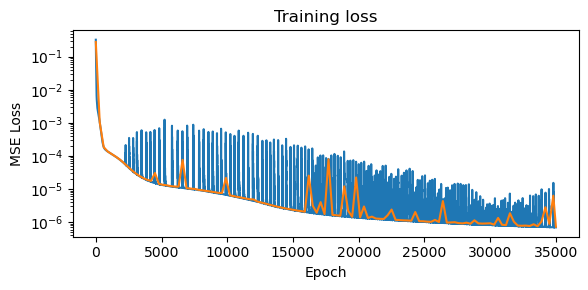

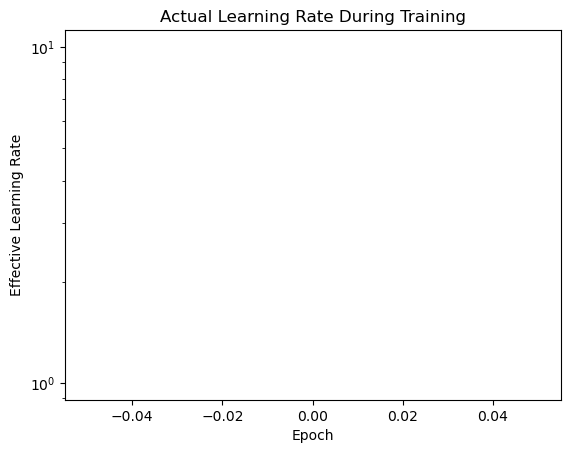

In [10]:
val = jnp.array(val)

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(lossesv2)
ax.semilogy(val_epochs, val)
ax.set(xlabel="Epoch", ylabel="MSE Loss", title="Training loss")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(lr_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Effective Learning Rate")
plt.title("Actual Learning Rate During Training")
plt.show()

In [11]:
import numpy as np

state = nnx.state(model)
flat = {str(k): np.asarray(v.value) for k, v in state.flat_state()}
np.savez("./EmulatorWork/sigma_40k_conv8.npz", **flat)

/tmp/ipykernel_3573261/2058552933.py:4: DeprecationWarning: '.value' access is now deprecated. For Variable[Array] instances use:

  variable[...]

For other Variable types use:

  variable.get_value()

  flat = {str(k): np.asarray(v.value) for k, v in state.flat_state()}


In [12]:
# import numpy as np

# saveray = np.array(x_val, y_val)
# np.savez("./EmulatorWork/val_data.npz")

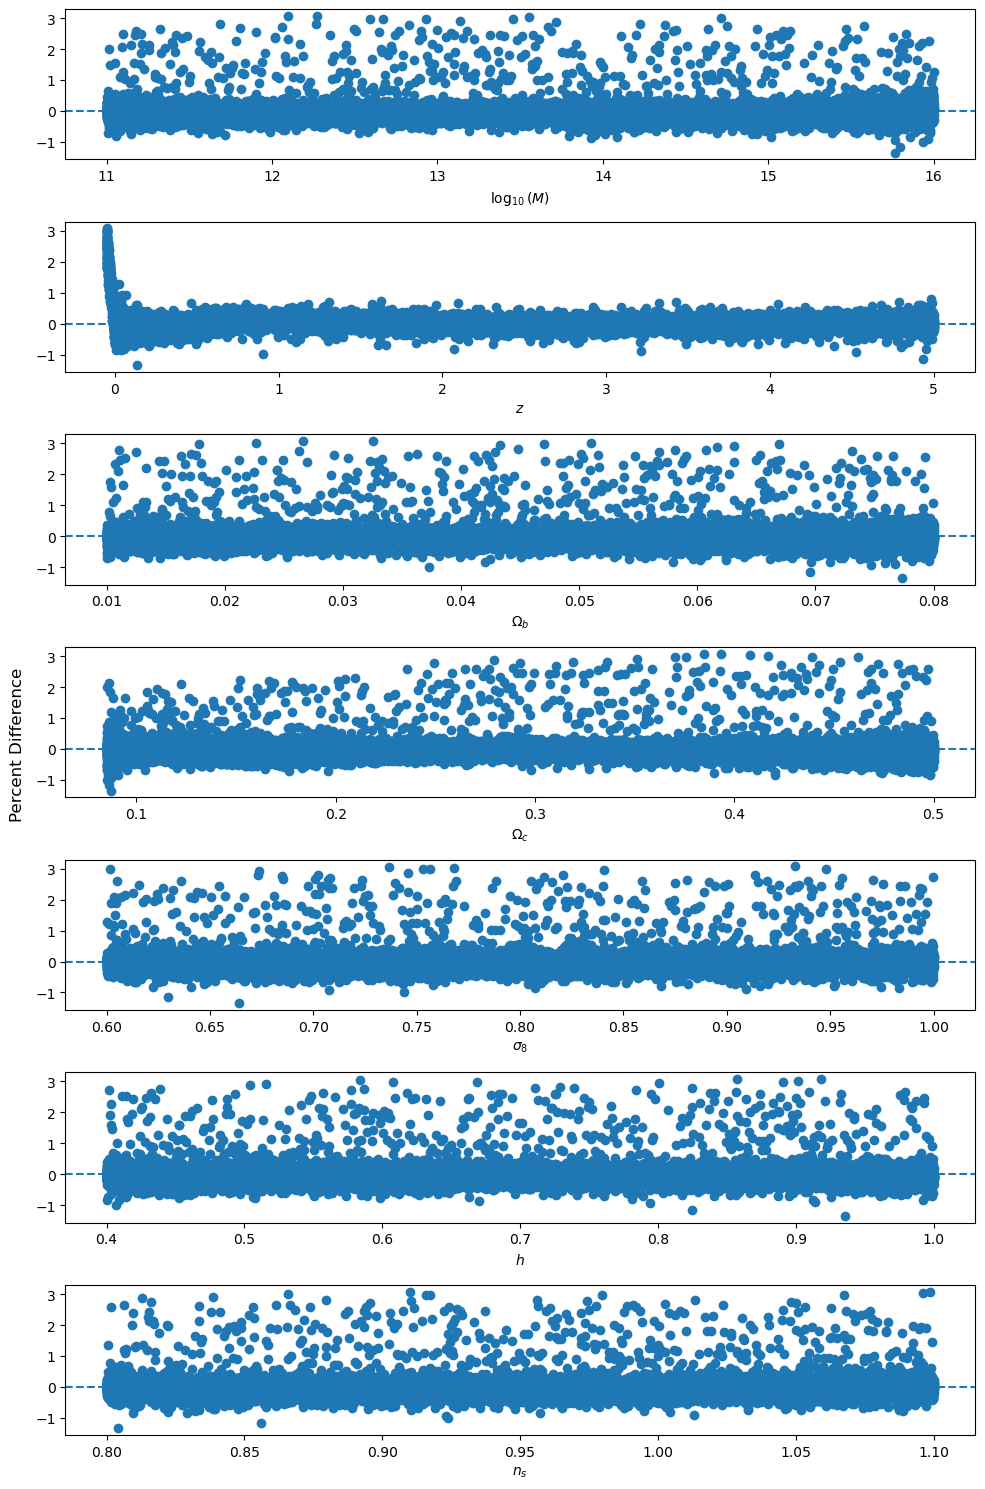

In [13]:
prediction = model(x_val_norm)

residual = (10**prediction - 10**y_val) / 10**y_val * 100 # now the absolute residual

predict_squ = {
    "residual": residual[::5],
    "logm": x_val[::5, 0],
    "z": x_val[::5, 1], 
    "Ob": x_val[::5, 2],
    "Oc": x_val[::5, 3],
    "s8": x_val[::5, 4],
    "h": x_val[::5, 5],
    "ns": x_val[::5, 6]
    }

# mask = (jnp.abs(residual) > 100)

# plt.scatter(x_val[:, 0][mask], y_val[mask], label = "validation points")
# plt.scatter(x_val[:, 0][mask], prediction[mask], label = "predicted points")
# plt.ylabel("hmf")
# plt.show()

fig, [ax1, ax2, ax3, ax4, ax5, ax6, ax7] = plt.subplots(7, figsize=(10,15))
ax1.axhline(0, linestyle="--")
ax1.scatter(x_val[:, 0], residual)
ax1.set_xlabel(r"$\log_{10}(M)$")

ax2.axhline(0, linestyle="--")
ax2.scatter(x_val[:, 1], residual)
ax2.set_xlabel(r"$z$")

ax3.axhline(0, linestyle="--")
ax3.scatter(x_val[:, 2], residual)
ax3.set_xlabel(r"$\Omega_b$")

ax4.axhline(0, linestyle="--")
ax4.scatter(x_val[:, 3], residual)
ax4.set_xlabel(r"$\Omega_c$")

ax5.axhline(0, linestyle="--")
ax5.scatter(x_val[:, 4], residual)
ax5.set_xlabel(r"$\sigma_8$")

ax6.axhline(0, linestyle="--")
ax6.scatter(x_val[:, 5], residual)
ax6.set_xlabel(r"$h$")

ax7.axhline(0, linestyle="--")
ax7.scatter(x_val[:, 6], residual)
ax7.set_xlabel(r"$n_s$")

# ax1.set_xlim(6,15)
# ax1.set_ylim(-10,10)

# ax2.set_xlim(0,4)
# ax2.set_ylim(-2,2)

fig.supylabel("Percent Difference")
fig.tight_layout()

<>:69: SyntaxWarning: invalid escape sequence '\o'
<>:69: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3573261/801176382.py:69: SyntaxWarning: invalid escape sequence '\o'
  fig.supxlabel("Mass [$M_\odot/h$]")


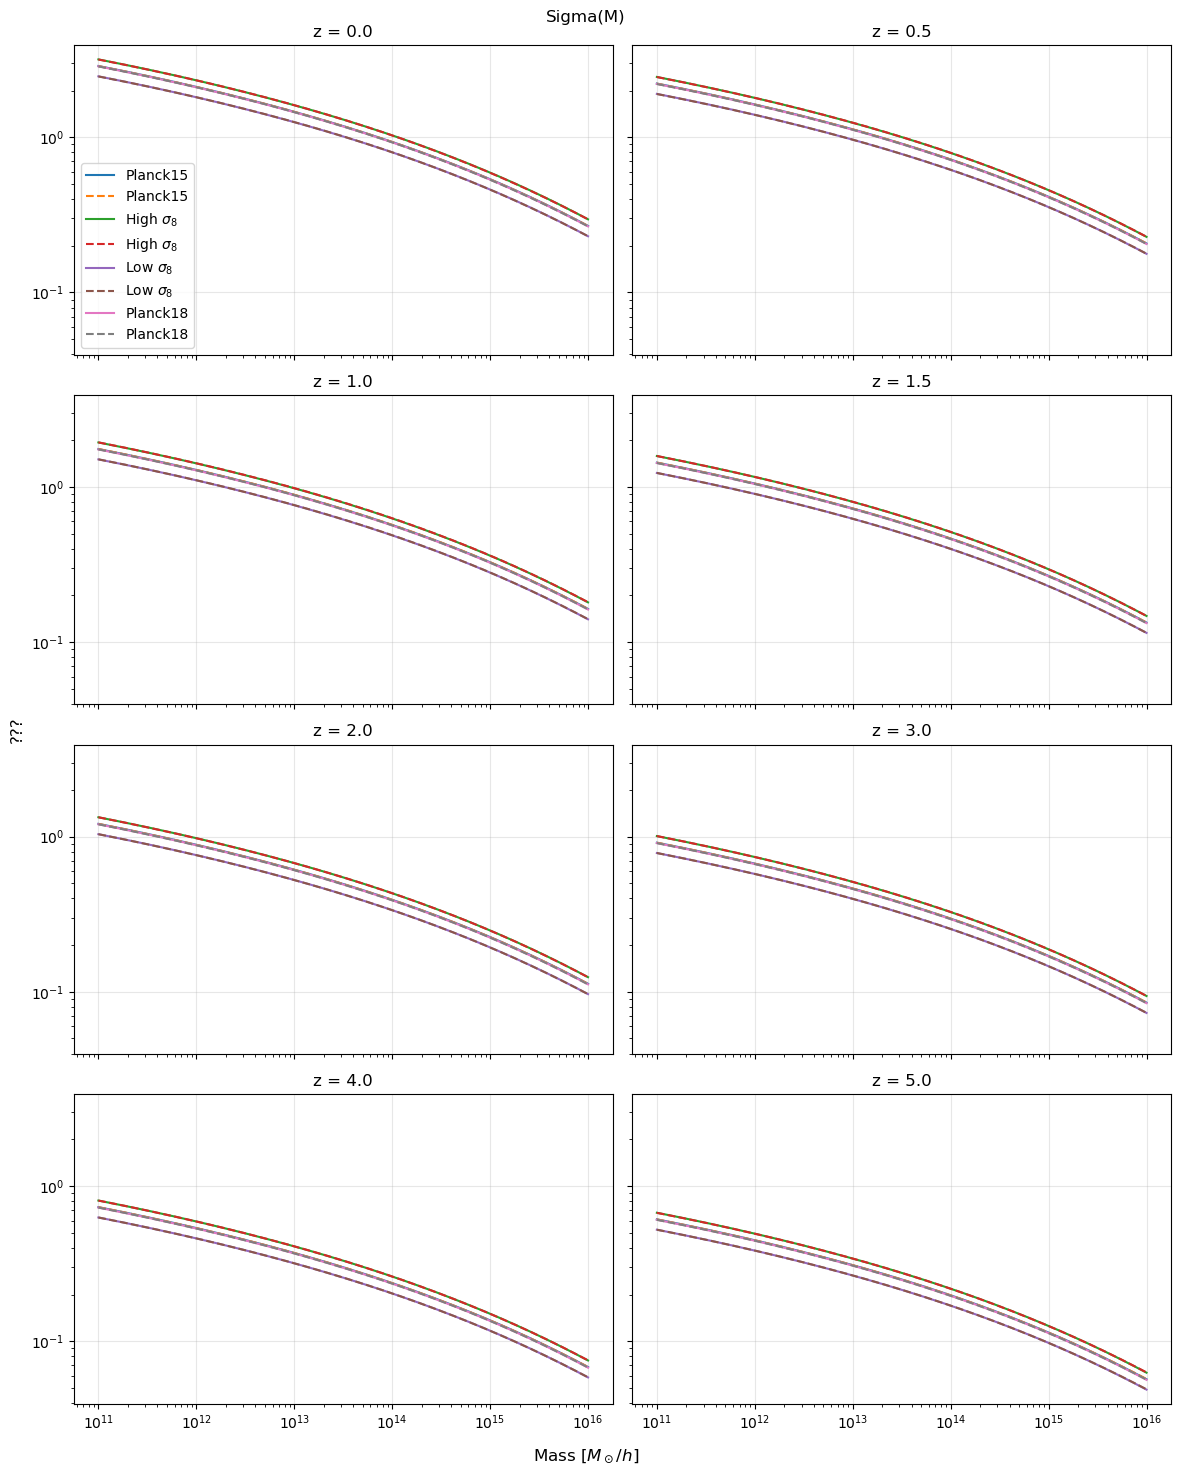

In [14]:
cosmo_fid = jc.Planck15()

cosmo_high_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.9,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

cosmo_low_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.7,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

cosmo_h = cosmology.Planck18()

cosmologies = [
    (r"Planck15", cosmo_fid),
    (r"High $\sigma_8$", cosmo_high_s8),
    (r"Low $\sigma_8$", cosmo_low_s8),
    (r"Planck18", cosmo_h)
]

masses = jnp.logspace(11, 16, 256)
zs = [0., 0.5, 1., 1.5, 2., 3., 4., 5.] #

halox_mass_vmap = jax.vmap(halox_trainer)

def build_input(masses, z, cosmo):
    logM = jnp.log10(masses)
    return jnp.column_stack([
        logM,
        jnp.full_like(logM, z),
        jnp.full_like(logM, cosmo.Omega_b),
        jnp.full_like(logM, cosmo.Omega_c),
        jnp.full_like(logM, cosmo.sigma8),
        jnp.full_like(logM, cosmo.h),
        jnp.full_like(logM, cosmo.n_s),
    ])


fig, axes = plt.subplots(4, 2, figsize=(12, 15), sharex=True, sharey=True)
axes = axes.flatten()

for ax, z in zip(axes, zs):
    
    for label, cosmo in cosmologies:
        
        x = build_input(masses, z, cosmo)
        x_norm = normalize(x)
        log_hmf_nn = model(x_norm)
        log_hmf = halox_mass_vmap(x)
        
        ax.plot(masses, 10**log_hmf, label=label)
        ax.plot(masses, 10**log_hmf_nn, label=label, linestyle="--")
    
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"z = {z}")
    ax.grid(alpha=0.3)
axes[0].legend()

fig.supxlabel("Mass [$M_\odot/h$]")
fig.supylabel("???")
fig.suptitle("Sigma(M)")

plt.tight_layout()
plt.show()

<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3573261/412169837.py:25: SyntaxWarning: invalid escape sequence '\o'
  fig.supxlabel("Mass [$M_\odot/h$]")
/tmp/ipykernel_3573261/412169837.py:29: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


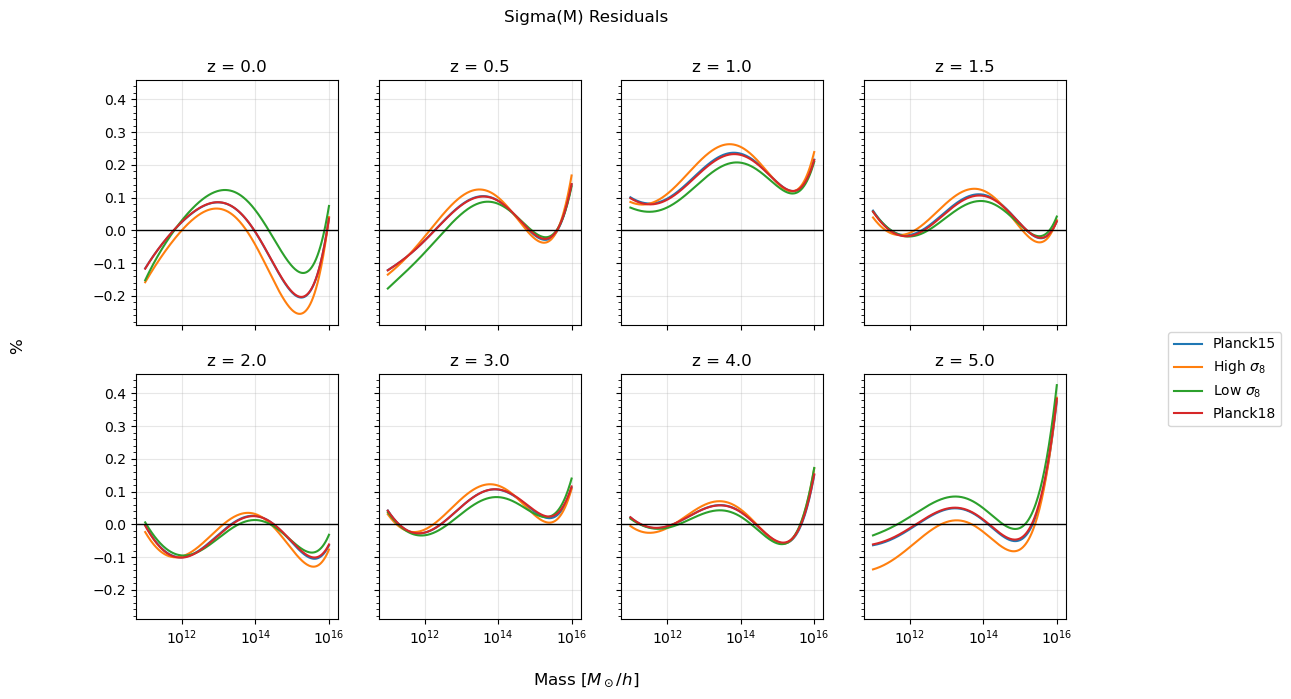

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.flatten()

for ax, z in zip(axes, zs):
    
    for label, cosmo in cosmologies:
        
        x = build_input(masses, z, cosmo)
        x_norm = normalize(x)
        log_hmf_nn = 10**model(x_norm)
        log_hmf_true = 10**halox_mass_vmap(x)
        
        residual = ((log_hmf_nn - log_hmf_true)/(log_hmf_true))*100  # dex residual
        ax.plot(masses, residual, label=label)
    
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xscale("log")
    # ax.set_ylim(-10,10)
    ax.set_title(f"z = {z}")
    ax.grid(alpha=0.3)
    ax.minorticks_on()

axes[0].legend(bbox_to_anchor = [5.7,0])

fig.supxlabel("Mass [$M_\odot/h$]")
fig.supylabel(r"%")
fig.suptitle("Sigma(M) Residuals")

plt.tight_layout()
plt.show()

In [16]:
def build_input(masses, z, cosmo):
    logM = jnp.log10(masses)
    
    return jnp.column_stack([
        logM,
        jnp.full_like(logM, z),
        jnp.full_like(logM, cosmo.Omega_b),
        jnp.full_like(logM, cosmo.Omega_c),
        jnp.full_like(logM, cosmo.sigma8),
        jnp.full_like(logM, cosmo.h),
        jnp.full_like(logM, cosmo.n_s),
    ])

cosmo_fid = jc.Planck15()

cosmo_high_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.9,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

cosmo_low_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.7,
    n_s=cosmo_fid.n_s,
    Omega_k=0, w0=-1, wa=0
)

cosmologies = [
    (r"Planck15", cosmo_fid),
    (r"High $\sigma_8$", cosmo_high_s8),
    (r"Low $\sigma_8$", cosmo_low_s8),
]

masses = jnp.logspace(9, 15, 256)
zs = [0., 0.5, 1., 1.5, 2., 3., 4., 5.] #

halox_mass_vmap = jax.vmap(halox_trainer)

import time


def benchmark(fn, x, n=1000):

    fn = jax.jit(fn)
    # warmup
    fn(x).block_until_ready()
    
    start = time.perf_counter()
    
    def loop(i, _):
        return fn(x)

    start = time.perf_counter()

    y = jax.lax.fori_loop(0, n, loop, fn(x))
    jax.block_until_ready(y)
    
    end = time.perf_counter()
    
    return (end - start) / n

x = build_input(masses, zs[0], cosmologies[0][1])

t_nn = benchmark(model, x)
t_true = benchmark(halox_mass_vmap, x)

print("NN time per call:", t_nn)
print("Analytic time per call:", t_true)
print("Speedup:", t_true / t_nn)

NN time per call: 0.00023588722199201583
Analytic time per call: 0.006871243593282997
Speedup: 29.129359086333093


[[<Axes: ylabel='logm'> None None None None None None]
 [<Axes: ylabel='z'> <Axes: > None None None None None]
 [<Axes: ylabel='Ob'> <Axes: > <Axes: > None None None None]
 [<Axes: ylabel='Oc'> <Axes: > <Axes: > <Axes: > None None None]
 [<Axes: ylabel='s8'> <Axes: > <Axes: > <Axes: > <Axes: > None None]
 [<Axes: ylabel='h'> <Axes: > <Axes: > <Axes: > <Axes: > <Axes: > None]
 [<Axes: xlabel='logm', ylabel='ns'> <Axes: xlabel='z'>
  <Axes: xlabel='Ob'> <Axes: xlabel='Oc'> <Axes: xlabel='s8'>
  <Axes: xlabel='h'> <Axes: xlabel='ns'>]]


/tmp/ipykernel_3573261/1436743262.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(x, y, c=colors, cmap=cmap, norm=norm, alpha=1, s=.15)


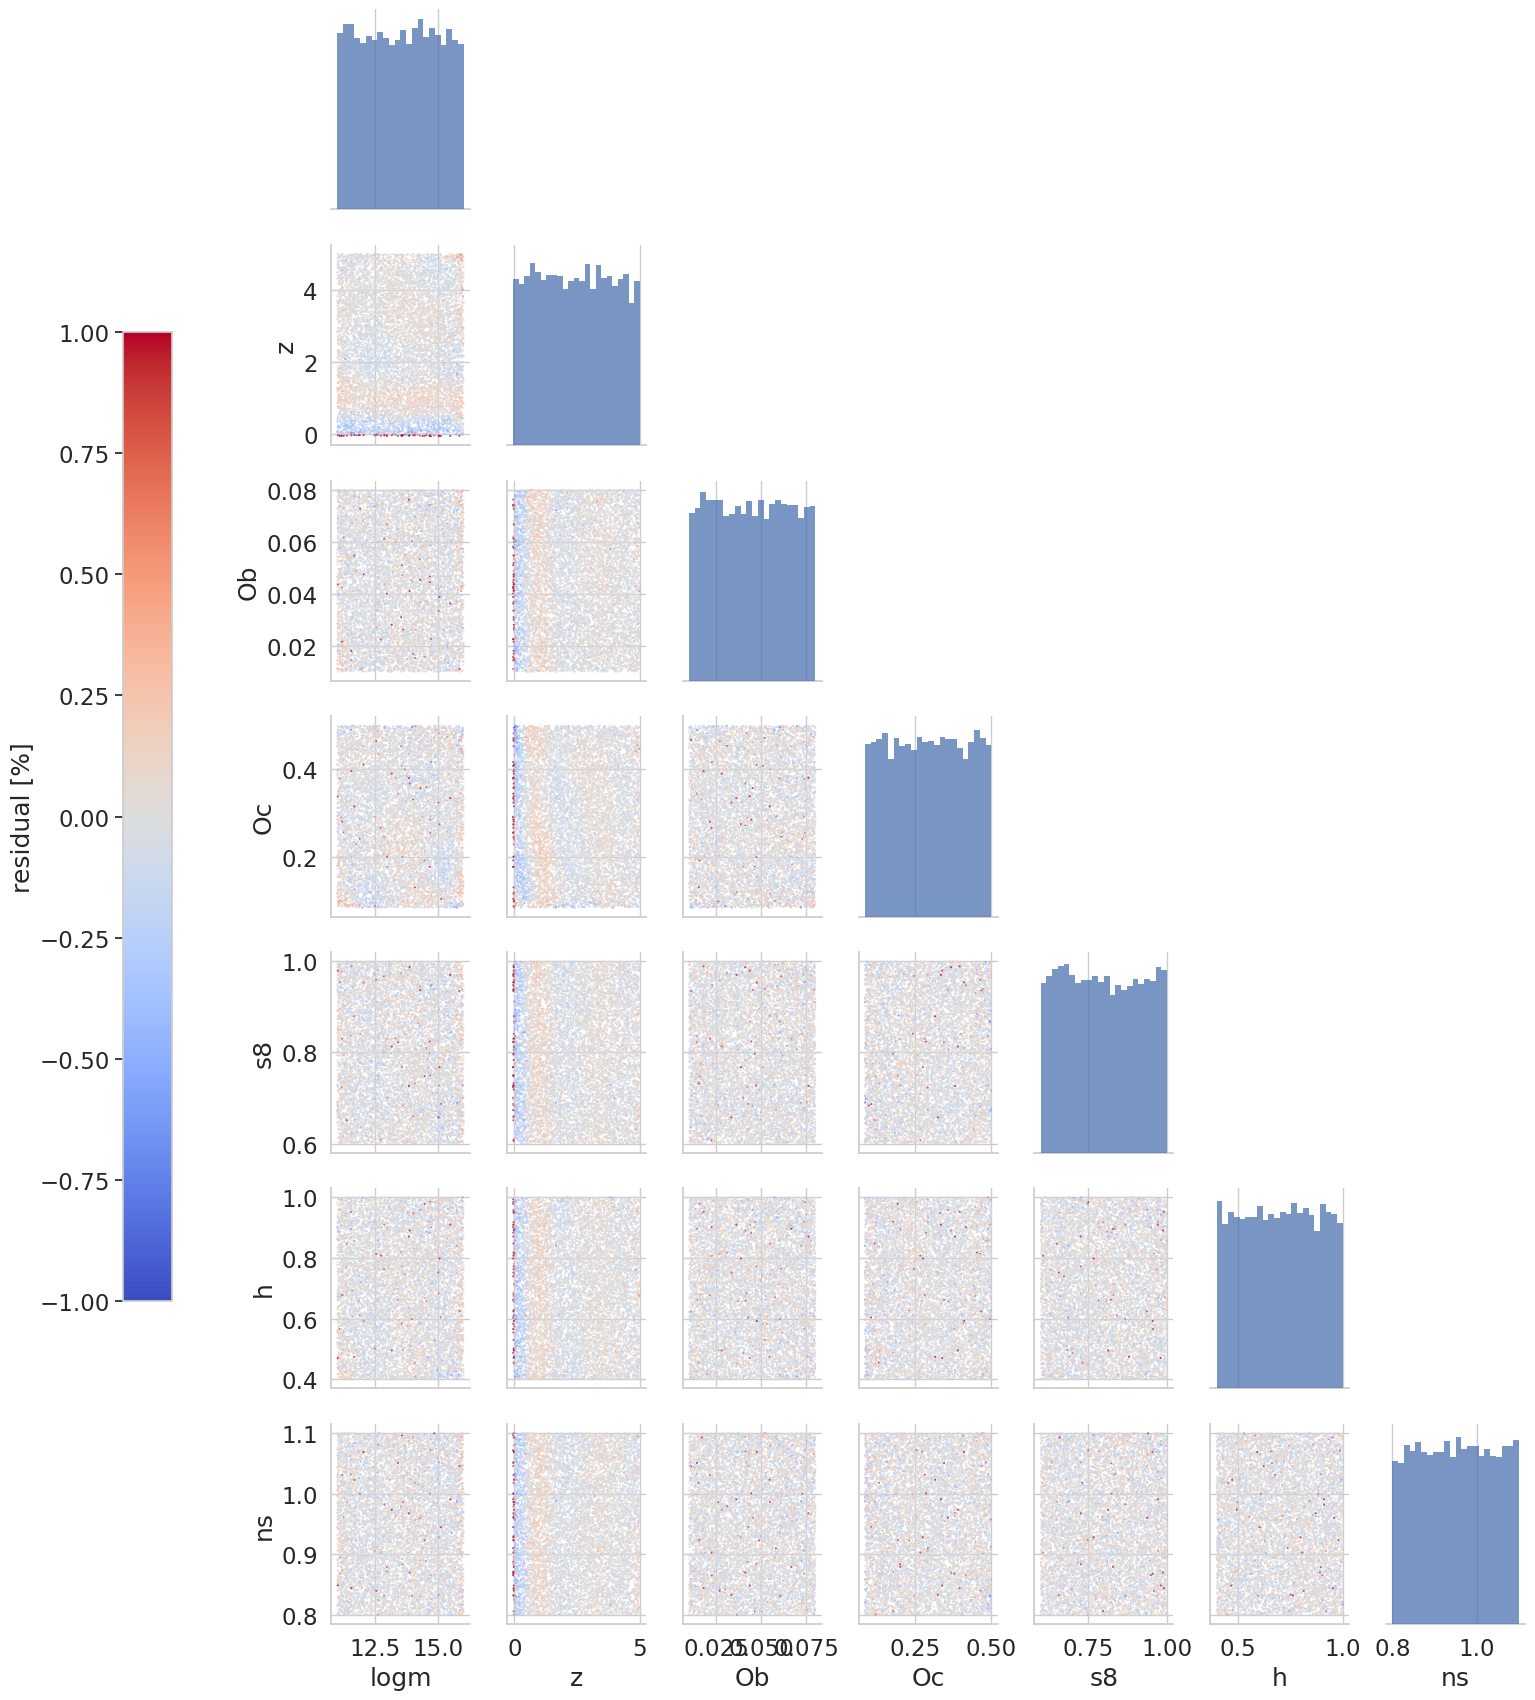

In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

data = pd.DataFrame(predict_squ)

# data.to_csv("emu_val.csv")

col_col = "residual"
plt_col = [k for k in data.columns if k != "residual"]

norm = mcolors.Normalize(vmin=-1.0, vmax=1.0)
cmap = cm.coolwarm
colors = cmap(norm(data[col_col].values))

sns.set_theme(style="whitegrid", font_scale=1.5)
g = sns.PairGrid(data, vars = plt_col, corner = True)
g.map_diag(sns.histplot, element="step", linewidth=0, kde=False)

def color_scatter(x, y, **kw):
    ax = plt.gca()
    ax.scatter(x, y, c=colors, cmap=cmap, norm=norm, alpha=1, s=.15)

axes = [ax for ax in g.axes.flat if ax is not None]

g.map_lower(color_scatter)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
print(g.axes)
g.figure.colorbar(sm, ax=axes, location = "left", label=f"{col_col} [%]", shrink=0.6)


bounds, model name
network width, number of epochs

In [18]:
data = {
    "param_bounds": bounds,
    "training_epochs": n_epochsv2,
    "network_width": nw,
}

with open("./EmulatorWork/conv8.txt", "w") as f:
    f.write("Run Configuration\n")
    f.write("=================\n\n")
    
    f.write(f"Training epochs: {n_epochsv2}\n")
    f.write(f"Network width: {nw}\n\n")
    
    f.write("Parameter bounds:\n")
    for i, b in enumerate(np.array(bounds)):
        f.write(f"  Param {i}: {b}\n")